# Hazard forecasts and impacts forecasts

In this tutorial,


## Table of Contents

1. [Reading in forecast data](#1-reading-in-forecast-data)
   - 1.1 [Using MeteoSwiss Open Government Data weather forecasts](#11-using-meteoswiss-open-government-data-weather-forecasts)
   - 1.2 [Using CLIMADA API demo data](#12-using-climada-api-demo-data)
2. [Impact calculation](#2-impact-calculation)
3. [Forecast products based on ImpactForecast](#3-forecast-products-based-on-impactforecast)
4. [Download and save data from MeteoSwiss Open Government Data](#download-and-save-data-from-meteoswiss-open-government-data)

In [1]:
# import necessary packages
import xarray as xr
import numpy as np
import numbers
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path

from climada.util.config import CONFIG
from climada.entity import ImpactFunc, ImpactFuncSet

DATA_DIR = Path(CONFIG.local_data.data_dir.str())
data_dir_hazard_forecast = DATA_DIR / "forecast" / "hazard"
data_dir_impact_forecast = DATA_DIR / "forecast" / "impact"

from climada.hazard.forecast import HazardForecast
from climada.engine import ImpactCalc

from climada.entity.exposures.litpop import LitPop


## 1. Reading in forecast data


### 1.1 Using MeteoSwiss Open Government Data weather forecasts

This example retrieves the latest OGD forecast data from MeteoSwiss.
You can also skip this step and go to section 1.2 for using stored demo data from the CLIMADA API.

Requires the package `meteodata-lab`, available via `pip`.

You can find out all about data openly published here (info and notebooks on how to retrieve):

Check out:
* https://github.com/MeteoSwiss/meteodata-lab and
* https://github.com/MeteoSwiss/opendata-nwp-demos/blob/main/01_retrieve_process_precip.ipynb
* https://www.meteoschweiz.admin.ch/service-und-publikationen/service/open-data.html



In [2]:
# optional packages for this section only
from meteodatalab import ogd_api
from meteodatalab.operators import time_operators as time_ops
from earthkit.data import config

config.set("cache-policy", "temporary")

earthkit-data cache: trying to free 9.2 GiB
earthkit-data cache: could not free 9.2 GiB


In [ ]:
# Define target lead times for ICON-CH2-EPS: up 5d, here +0h, to +12h
lead_times = [f"P0DT{i}H" for i in np.arange(0, 13)]
model = "ogd-forecasting-icon-ch2"
nwp_vars = ["TOT_PREC", "VMAX_10M"]  # precip. and wind; temperature: "T_2M"
reftime = "latest"  # also try: 'latest'

In [10]:
dict_ens_data = {}
for var in nwp_vars:
    req = ogd_api.Request(
        collection=model,
        variable=var,
        ref_time=reftime,
        perturbed=True,  # ensembles
        lead_time=lead_times,
    )
    dict_ens_data[var] = ogd_api.get_from_ogd(req)

dict_ens_data["TOT_PREC"] = time_ops.delta(
    dict_ens_data["TOT_PREC"], np.timedelta64(1, "h")
)

earthkit-data cache: trying to free 9.2 GiB
Deleting entry {
    "path": "/var/folders/04/tbpkdd855mg6mjr2mj6h1csh0000gp/T/tmpi2aprro0/url-7ddd7f2f8a2c6165135cfe7facb51dad6776775fcbc6857350755e17ac51e9ac.grib2",
    "owner": "url",
    "args": {
        "url": [
            "https://rgw.cscs.ch/cscs.meteoswiss.ogd.nwp.static/horizontal_constants_icon-ch2-eps.grib2?AWSAccessKeyId=13GC1T4NT2CY1N0L92YC&Signature=wd8C3uRUERtD2ez54LKVoECJ79E%3D&Expires=1768120593"
        ],
        "parts": [
            null
        ]
    },
    "creation_date": "2025-12-11 11:22:30.466478",
    "flags": 0,
    "owner_data": {},
    "last_access": "2025-12-11 11:22:30.466478",
    "type": "file",
    "parent": null,
    "replaced": null,
    "extra": null,
    "expires": null,
    "accesses": 1,
    "size": 2839635
}
earthkit-data cache: deleting /var/folders/04/tbpkdd855mg6mjr2mj6h1csh0000gp/T/tmpi2aprro0/url-7ddd7f2f8a2c6165135cfe7facb51dad6776775fcbc6857350755e17ac51e9ac.grib2 (2.7 MiB)
earthkit-data c

In [ ]:
ds_icon_latest = xr.Dataset(dict_ens_data)
init_time_str = np.datetime_as_string(ds_icon_latest.ref_time.values[0], unit="h")

In [25]:
haz_fc_icon_latest = HazardForecast.from_xarray_raster(
    ds_icon_latest,
    hazard_type="PR",
    intensity_unit="mm/h",
    coordinate_vars={
        "longitude": "lon",
        "latitude": "lat",
        "lead_time": "lead_time",
        "member": "eps",
    },
    intensity="TOT_PREC",
)

2025-12-11 11:27:33,362 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates. Hazard.event_name will be empty strings
2025-12-11 11:27:33,364 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates or ordinals. Hazard.date will be ones only


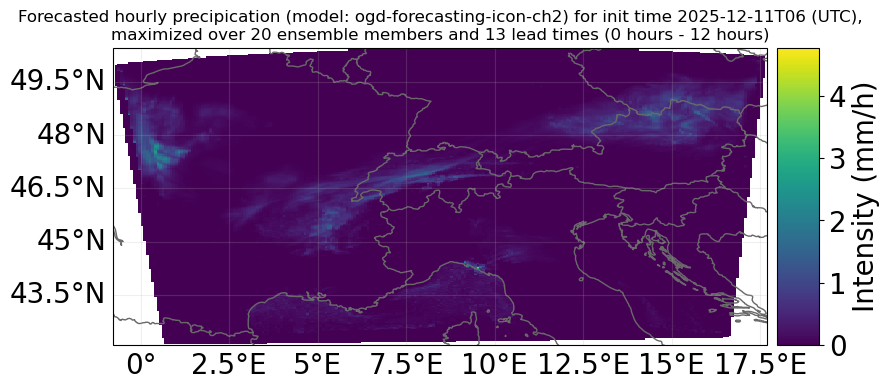

In [65]:
# check if there is precipitation in the forecast
ax = haz_fc_icon_latest.plot_intensity(event=0)
lead_times = np.unique(haz_fc_icon_latest.lead_time).astype("timedelta64[h]")
ax.set_title(
    f"Forecasted hourly precipication (model: {model}) for init time {init_time_str} (UTC),\n"
    f"maximized over {len(np.unique(haz_fc_icon_latest.member))} ensemble members and {len(lead_times)} lead times ({lead_times[0]} - {lead_times[-1]})"
);


### 1.2 Using CLIMADA API demo data

In [2]:
# temporary local path
path_to_forecast_nc = "/Users/vgebhart/Documents/climada/data/forecast/hazard/fcst_icon_seamless_2024-06-18_12_00.nc"

In [3]:
hazard_forecast = HazardForecast.from_xarray_raster(
    path_to_forecast_nc,
    hazard_type="PR",
    intensity_unit="mm/h",
    coordinate_vars={
        "longitude": "x",
        "latitude": "y",
        "lead_time": "lead_time",
        "member": "realization",
    },
    intensity="precipitation_amount_1hsum",
    crs="EPSG:2056",
)
# transform to EPSG:4326
hazard_forecast.centroids.gdf = hazard_forecast.centroids.gdf.to_crs(epsg=4326)

/Users/vgebhart/gitprojects/climada_repo/climada_python/climada/hazard/forecast.py:413: FutureWarning: In a future version, xarray will not decode the variable 'lead_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  dset = xr.open_dataset(data, **open_dataset_kws)


2025-12-11 09:15:14,756 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates. Hazard.event_name will be empty strings
2025-12-11 09:15:14,758 - climada.hazard.xarray - WARNING - Failed to read values of 'event' as dates or ordinals. Hazard.date will be ones only


Text(0.5, 1.0, 'Precipation Forecast for member 10 and lead time 78 hours')

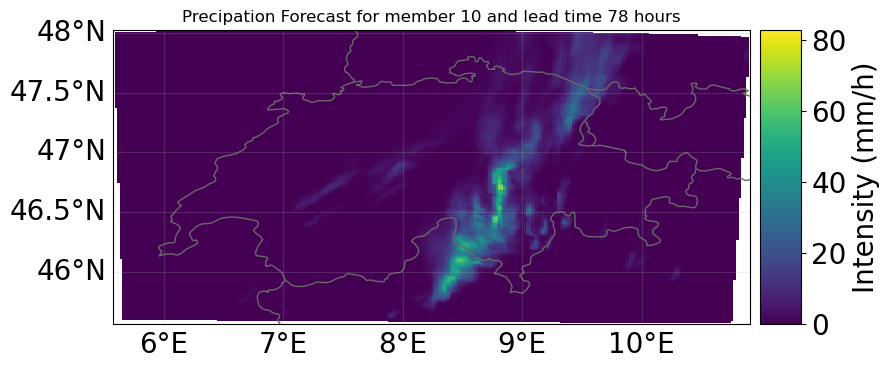

In [116]:
# plot hazard forecast for one member  and one lead time
id_member = 10
id_lead_time = 78
test_member = hazard_forecast.member[id_member]
test_lead_time = np.unique(hazard_forecast.lead_time)[id_lead_time]
ax = hazard_forecast.select(
    member=test_member,
    lead_time=test_lead_time,
).plot_intensity(0)
ax.set_title(
    f"Precipation Forecast for member {hazard_forecast.member[id_member]} and lead time {np.unique(hazard_forecast.lead_time)[id_lead_time].astype('timedelta64[h]')}"
)

In [ ]:
# plot median over member dimension for given a lead time
# ax = (
#     hazard_forecast.max(dim="member")
#     .select(lead_time=test_lead_time)
#     .plot_intensity(0)
# )
# ax.set_title(
#     f"Hazard Forecast for member {hazard_forecast.member[id_member]} and lead time {hazard_forecast.lead_time[id_lead_time]}"
# )

## 2. Impact calculation

2025-12-11 11:15:01,931 - climada.entity.exposures.litpop.litpop - INFO - 
 LitPop: Init Exposure for country: CHE (756)...

2025-12-11 11:15:02,154 - climada.entity.exposures.litpop.litpop - INFO - 
 LitPop: Init Exposure for country: LIE (438)...

2025-12-11 11:15:02,227 - climada.entity.exposures.base - INFO - Hazard type not set in impf_
2025-12-11 11:15:02,227 - climada.entity.exposures.base - INFO - category_id not set.
2025-12-11 11:15:02,227 - climada.entity.exposures.base - INFO - cover not set.
2025-12-11 11:15:02,228 - climada.entity.exposures.base - INFO - deductible not set.
2025-12-11 11:15:02,228 - climada.entity.exposures.base - INFO - centr_ not set.
2025-12-11 11:15:02,238 - climada.entity.exposures.base - INFO - Matching 70525 exposures with 27000 centroids.
2025-12-11 11:15:02,299 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 100 degree


<Axes: title={'center': 'PR 1: '}, xlabel='Intensity ()', ylabel='Impact (%)'>

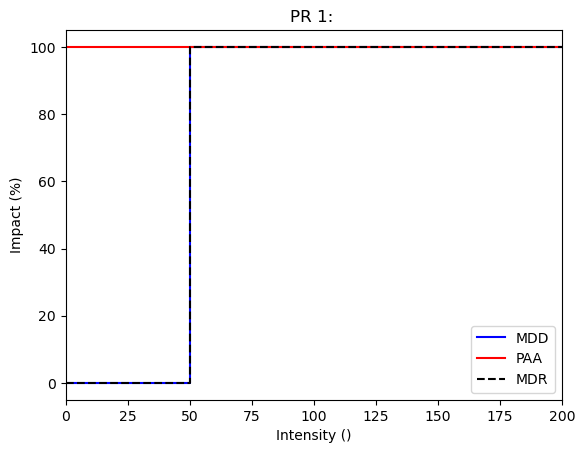

In [111]:
# Read exposure for population
exp_che = LitPop.from_population(countries=["CHE", "LIE"], res_arcsec=30)

# Assign centroids because hazard not on regular grid
exp_che.assign_centroids(hazard_forecast, threshold=100)


# define impact functions
threshold_for_affected = 50
imp_fun_precip = ImpactFunc.from_step_impf(
    (0, threshold_for_affected, 200), haz_type=f"PR", impf_id=1
)

impf_set = ImpactFuncSet([imp_fun_precip])
impf_set.plot()

In [112]:
# calculate impact
impact_forecast = ImpactCalc(exp_che, impf_set, hazard_forecast).impact(
    save_mat=True,
    assign_centroids=False,  # assign_centroid=False because we do not want to reassign centroids
)

2025-12-11 11:15:02,595 - climada.entity.exposures.base - INFO - No specific impact function column found for hazard PR. Using the anonymous 'impf_' column.
2025-12-11 11:15:02,600 - climada.engine.impact_calc - INFO - Calculating impact for 208182 assets (>0) and 2415 events.
2025-12-11 11:15:02,878 - climada.engine.impact_calc - WARNING - eai_exp and aai_agg are undefined with forecasts. Setting them to NaN arrays.
2025-12-11 11:15:02,892 - climada.engine.impact - WARNING - The Impact.tot_value attribute is deprecated.Use Exposures.affected_total_value to calculate the affected total exposure value based on a specific hazard intensity threshold
2025-12-11 11:15:02,892 - climada.engine.impact_forecast - WARNING - at_event gives the total impact for one specific combination of member and lead_time.


## 3. Forecast products based on ImpactForecast

In [ ]:
impact_forecast_sel = impact_forecast.select(
    member=test_member,
    lead_time=test_lead_time,
)

2025-12-11 11:15:04,116 - climada.engine.impact - INFO - The eai_exp and aai_agg are computed for the selected subset of events WITHOUT modification of the frequencies.


In [114]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

admin1 = cfeature.NaturalEarthFeature(
    category="cultural", name="admin_1_states_provinces_lines", scale="10m"
)
lakes = cfeature.LAKES.with_scale("10m")
borders = cfeature.BORDERS.with_scale("10m")
extent_ticino = [8.2, 9.3, 45.58, 47]

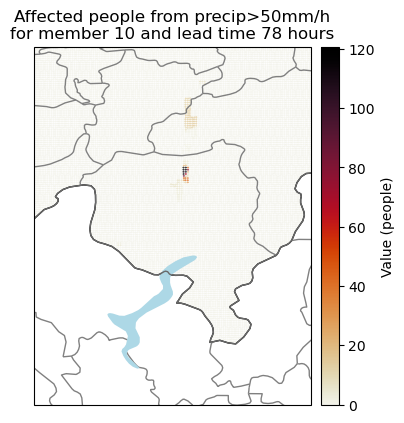

In [117]:
fig = plt.figure(figsize=(6, 4))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(borders, linewidth=1)
ax.add_feature(admin1, edgecolor="gray", linewidth=1.0, facecolor="none")
ax.add_feature(lakes, facecolor="lightblue")

# Zoom in on Switzerland
impact_forecast_sel.plot_hexbin_impact_exposure(
    event_id=impact_forecast_sel.event_id, buffer=10.0, pop_name=False, axis=ax
)
ax.set_extent(extent_ticino)
ax.set_title(
    f"Affected people from precip>{threshold_for_affected}mm/h\nfor member {test_member} and lead time {test_lead_time.astype('timedelta64[h]')}"
)
plt.show()

In [ ]:
average_total_impact_per_leadtime = impact_forecast.mean(
    dimension="member"
).imp_mat.sum(axis=1)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(impact_forecast.lead_time, average_total_impact_per_leadtime)
ax.set_xlabel("Lead time")
ax.set_ylabel("Number of people")
ax.set_title("Number of impacted people in CH per lead time (ensemble average)")

In [ ]:
# per member map of maximum precip over leatimes

# plt.subplots(7, 3, )

In [ ]:
# per lead time histogram over members aggrevated over switzerland

# plt.subplots(7, 3, )

In [42]:
# show that some methods and attributes are blocked